# Phase 2: Data Understanding
**CRISP-DM Purpose:** Become familiar with the data's structure, quality, variables, and relationships before any transformation.

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))
from src.config import AT_RISK_DAYS
from src.features import build_donation_features, add_label

sns.set_theme(style='whitegrid', palette='muted')

# Load raw data — checks data/raw/ first, falls back to pipeline/ folder
raw_dir = Path('..') / 'data' / 'raw'
fallback_dir = Path('..').parent

def find_csv(name):
    p = raw_dir / name
    return p if p.exists() else fallback_dir / name

supporters = pd.read_csv(find_csv('../../datasets/supporters.csv'), parse_dates=['created_at', 'first_donation_date'])
donations  = pd.read_csv(find_csv('../../datasets/donations.csv'),  parse_dates=['donation_date'])

print(f'supporters: {supporters.shape[0]} rows × {supporters.shape[1]} columns')
print(f'donations:  {donations.shape[0]} rows  × {donations.shape[1]} columns')

supporters: 60 rows × 15 columns
donations:  420 rows  × 13 columns


## 2.1 Data Description

In [6]:
print('=== SUPPORTERS — sample rows ===')
display(supporters.head(3))
print('\n=== DONATIONS — sample rows ===')
display(donations.head(3))

=== SUPPORTERS — sample rows ===


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia



=== DONATIONS — sample rows ===


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN


## 2.2 Univariate Statistics + Missingness Report

In [7]:
def missingness_report(df, name):
    desc = df.describe(include='all').T
    desc['missing']     = df.isnull().sum()
    desc['missing_pct'] = (df.isnull().mean() * 100).round(1)
    desc['nunique']     = df.nunique()
    desc['dtype']       = df.dtypes
    cols = ['dtype', 'count', 'missing', 'missing_pct', 'nunique']
    print(f'\n=== {name} ===')
    display(desc[cols])

missingness_report(supporters, 'SUPPORTERS')
missingness_report(donations,  'DONATIONS')


=== SUPPORTERS ===


,dtype,count,missing,missing_pct,nunique
supporter_id,int64,60.0,0,0.0,60
supporter_type,str,60,0,0.0,6
display_name,str,60,0,0.0,60
organization_name,str,4,56,93.3,4
first_name,str,56,4,6.7,56
last_name,str,56,4,6.7,55
relationship_type,str,60,0,0.0,3
region,str,60,0,0.0,3
country,str,60,0,0.0,4
email,str,60,0,0.0,60



=== DONATIONS ===


,dtype,count,missing,missing_pct,nunique
donation_id,int64,420.0,0,0.0,420
supporter_id,int64,420.0,0,0.0,59
donation_type,str,420,0,0.0,5
donation_date,datetime64[us],420,0,0.0,350
is_recurring,bool,420,0,0.0,2
campaign_name,str,145,275,65.5,4
channel_source,str,420,0,0.0,5
currency_code,str,234,186,44.3,1
amount,float64,234.0,186,44.3,224
estimated_value,float64,420.0,0,0.0,390


### Data Quality Notes

| Column | Null Behaviour | Classification |
|---|---|---|
| `supporters.organization_name` | Null for individuals | **By design** — organizations have this; individuals do not |
| `supporters.first_name` / `last_name` | Null for PartnerOrganization rows | **By design** |
| `supporters.first_donation_date` | 1 null observed | **Acceptable** — supporter created before first donation recorded |
| `donations.amount` | Null for non-monetary types (Time, InKind, Skills, SocialMedia) | **By design** — use `estimated_value` as the universal metric |
| `donations.currency_code` | Null for non-monetary | **By design** |
| `donations.campaign_name` | Null if not campaign-driven | **Expected** |
| `donations.referral_post_id` | Null if not social-media-referred | **Expected** |

> **Key decision:** Use `estimated_value` (not `amount`) for all monetary aggregations. It is populated for all donation types and expressed in the unit given by `impact_unit`.

## 2.3 Target Distribution

=== All supporters — status ===
status
Active      45
Inactive    15
Name: count, dtype: int64

=== at_risk label (active donors only, 90-day window) ===
at_risk
At risk (1)        34
Not at risk (0)    11
Name: count, dtype: int64

Imbalance ratio: 3.1:1
✓ Imbalance ratio < 4:1 — standard training is acceptable.


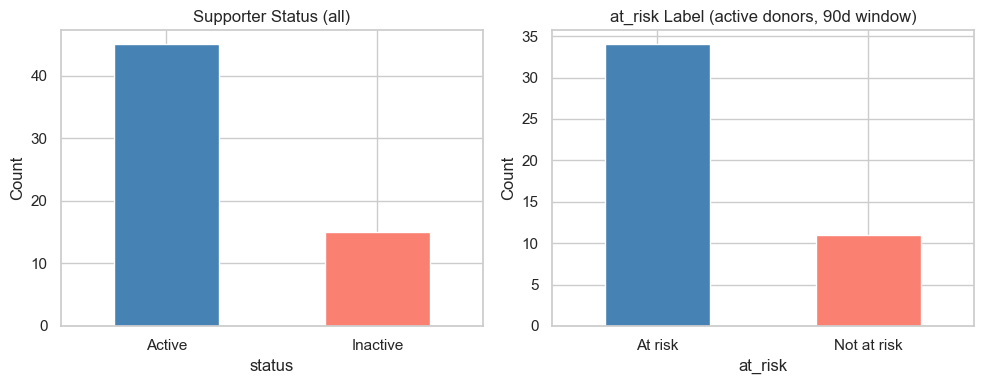

In [8]:
df = build_donation_features(supporters, donations)
df = add_label(df, at_risk_days=AT_RISK_DAYS)

# Overall status distribution
print('=== All supporters — status ===')
print(supporters['status'].value_counts())

# at_risk label among active donors only
active = df[df['status'] == 'Active'].copy()
label_counts = active['at_risk'].value_counts()
ratio = label_counts.max() / label_counts.min()

print(f'\n=== at_risk label (active donors only, {AT_RISK_DAYS}-day window) ===')
print(label_counts.rename({0: 'Not at risk (0)', 1: 'At risk (1)'}))
print(f'\nImbalance ratio: {ratio:.1f}:1')

if ratio >= 4:
    print('⚠ Imbalance ratio ≥ 4:1 — will apply class_weight="balanced" and report per-class metrics.')
else:
    print('✓ Imbalance ratio < 4:1 — standard training is acceptable.')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
supporters['status'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=0)
axes[0].set_title('Supporter Status (all)')
axes[0].set_ylabel('Count')

active['at_risk'].value_counts().rename({0: 'Not at risk', 1: 'At risk'}).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'salmon'], rot=0)
axes[1].set_title(f'at_risk Label (active donors, {AT_RISK_DAYS}d window)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2.4 Categorical Feature Distributions

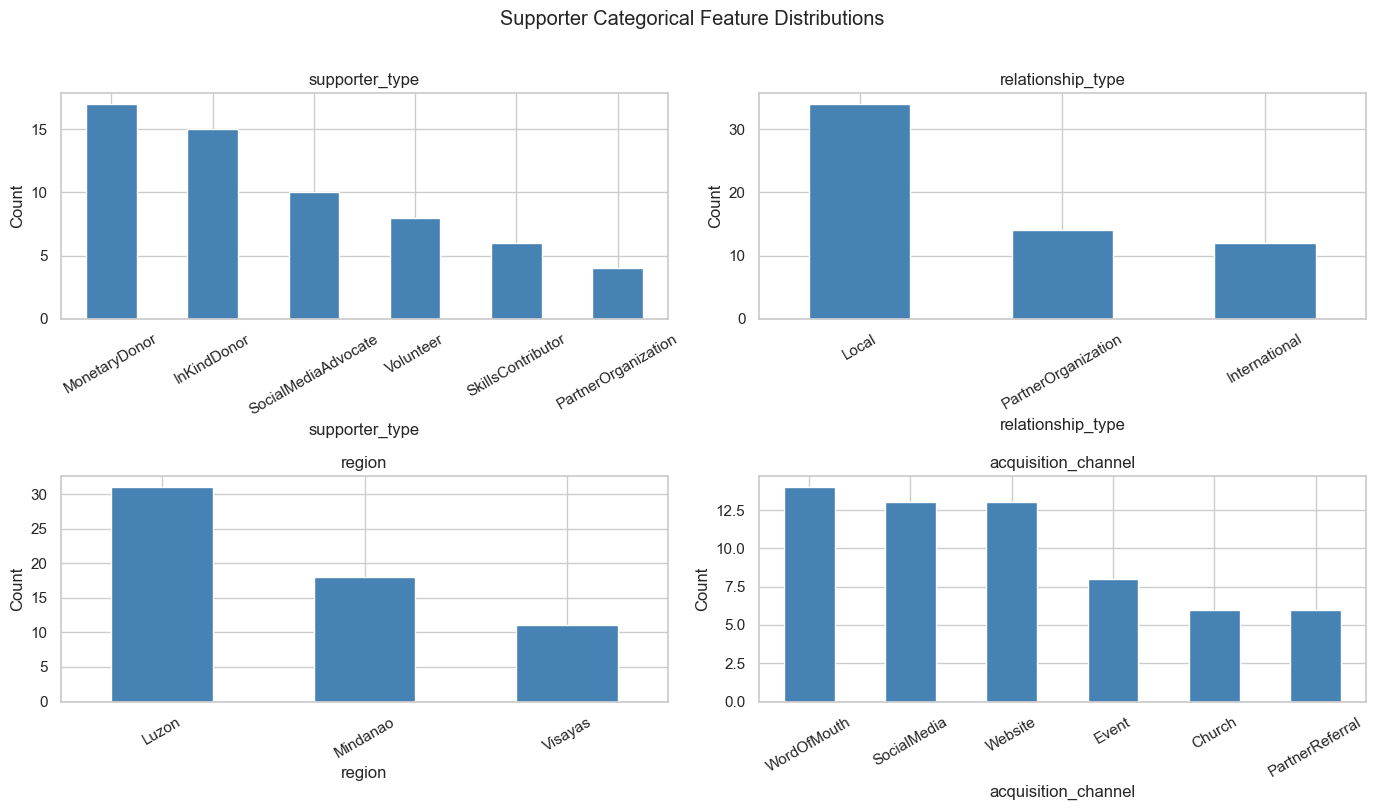

In [9]:
cat_cols = ['supporter_type', 'relationship_type', 'region', 'acquisition_channel']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, cat_cols):
    supporters[col].value_counts().plot(kind='bar', ax=ax, rot=30, color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.suptitle('Supporter Categorical Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

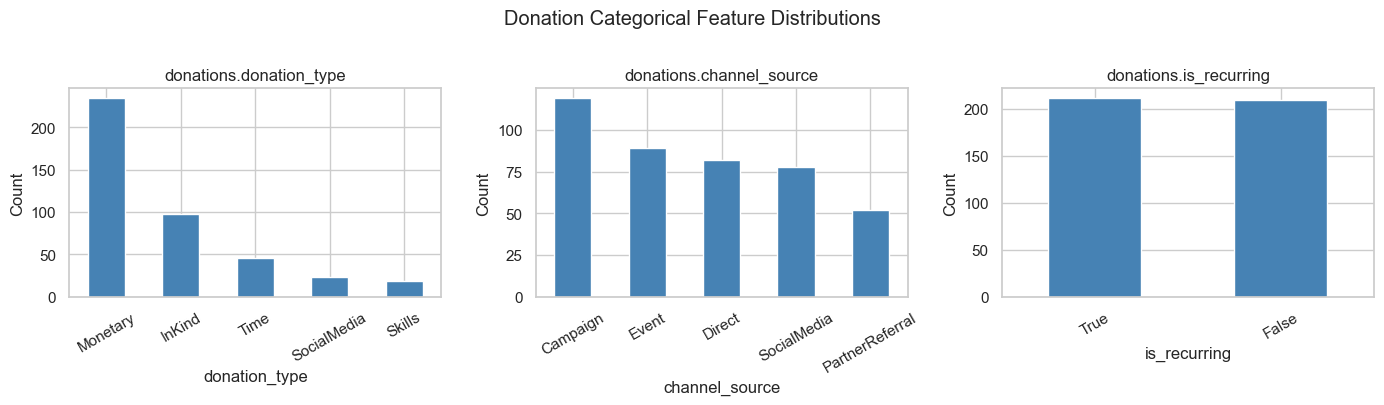

In [10]:
don_cat_cols = ['donation_type', 'channel_source', 'is_recurring']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, don_cat_cols):
    donations[col].value_counts().plot(kind='bar', ax=ax, rot=30, color='steelblue')
    ax.set_title(f'donations.{col}')
    ax.set_ylabel('Count')
plt.suptitle('Donation Categorical Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

## 2.5 Donation Numeric Feature Distributions

estimated_value distribution (all donation types):
count     420.000000
mean      699.304310
std       713.251586
min         2.200000
25%       300.000000
50%       514.160000
75%       989.722500
max      6481.540000
Name: estimated_value, dtype: float64


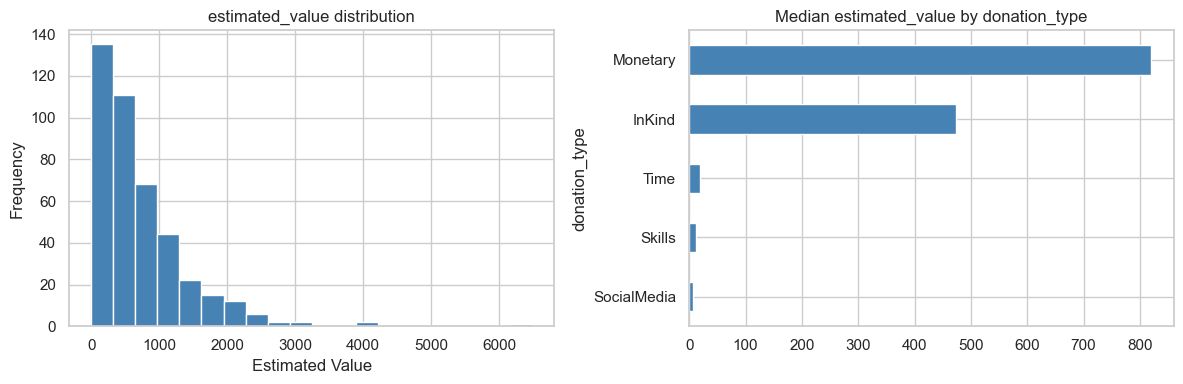

In [11]:
print('estimated_value distribution (all donation types):')
print(donations['estimated_value'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
donations['estimated_value'].dropna().plot(kind='hist', bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('estimated_value distribution')
axes[0].set_xlabel('Estimated Value')

donations.groupby('donation_type')['estimated_value'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Median estimated_value by donation_type')
plt.tight_layout()
plt.show()

## 2.6 Engineered Feature Distributions (joined dataset)

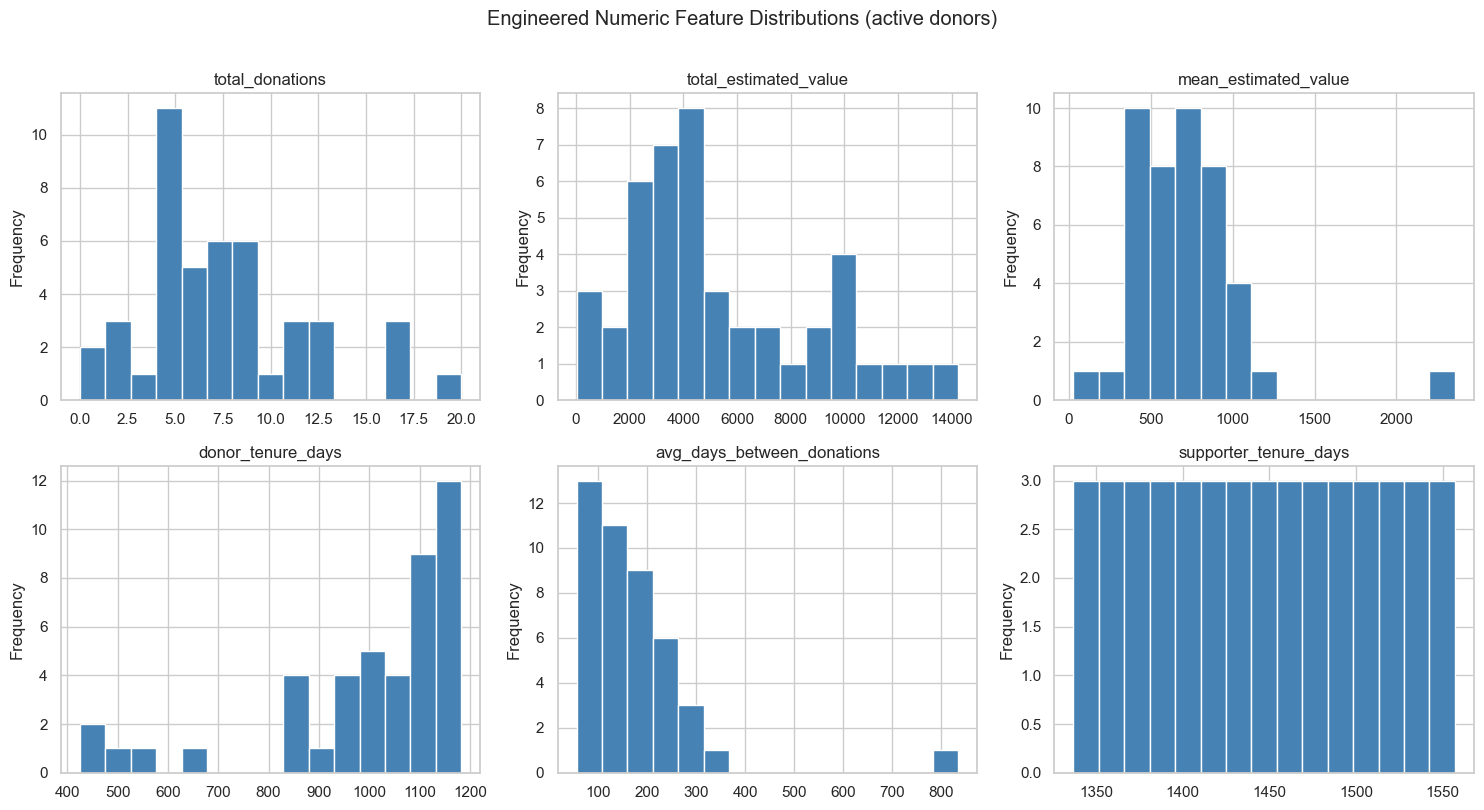


Descriptive stats for engineered features:


,total_donations,total_estimated_value,mean_estimated_value,donor_tenure_days,avg_days_between_donations,supporter_tenure_days
count,45.0,44.0,44.0,44.0,44.0,45.0
mean,7.4,5323.1,695.4,997.7,174.3,1447.0
std,4.4,3492.0,352.5,202.7,122.6,65.7
min,0.0,27.1,27.1,425.0,56.6,1337.0
25%,5.0,2883.8,469.3,952.2,105.2,1392.0
50%,7.0,4361.2,681.4,1057.5,147.2,1447.0
75%,9.0,7469.2,841.9,1134.2,203.0,1502.0
max,20.0,14240.3,2356.9,1183.0,834.0,1557.0


In [12]:
num_features = [
    'total_donations', 'total_estimated_value', 'mean_estimated_value',
    'donor_tenure_days', 'avg_days_between_donations', 'supporter_tenure_days'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_features):
    active[col].dropna().plot(kind='hist', bins=15, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Engineered Numeric Feature Distributions (active donors)', y=1.01)
plt.tight_layout()
plt.show()

print('\nDescriptive stats for engineered features:')
display(active[num_features].describe().round(1))

## 2.7 Relationship Exploration — at_risk vs Key Features

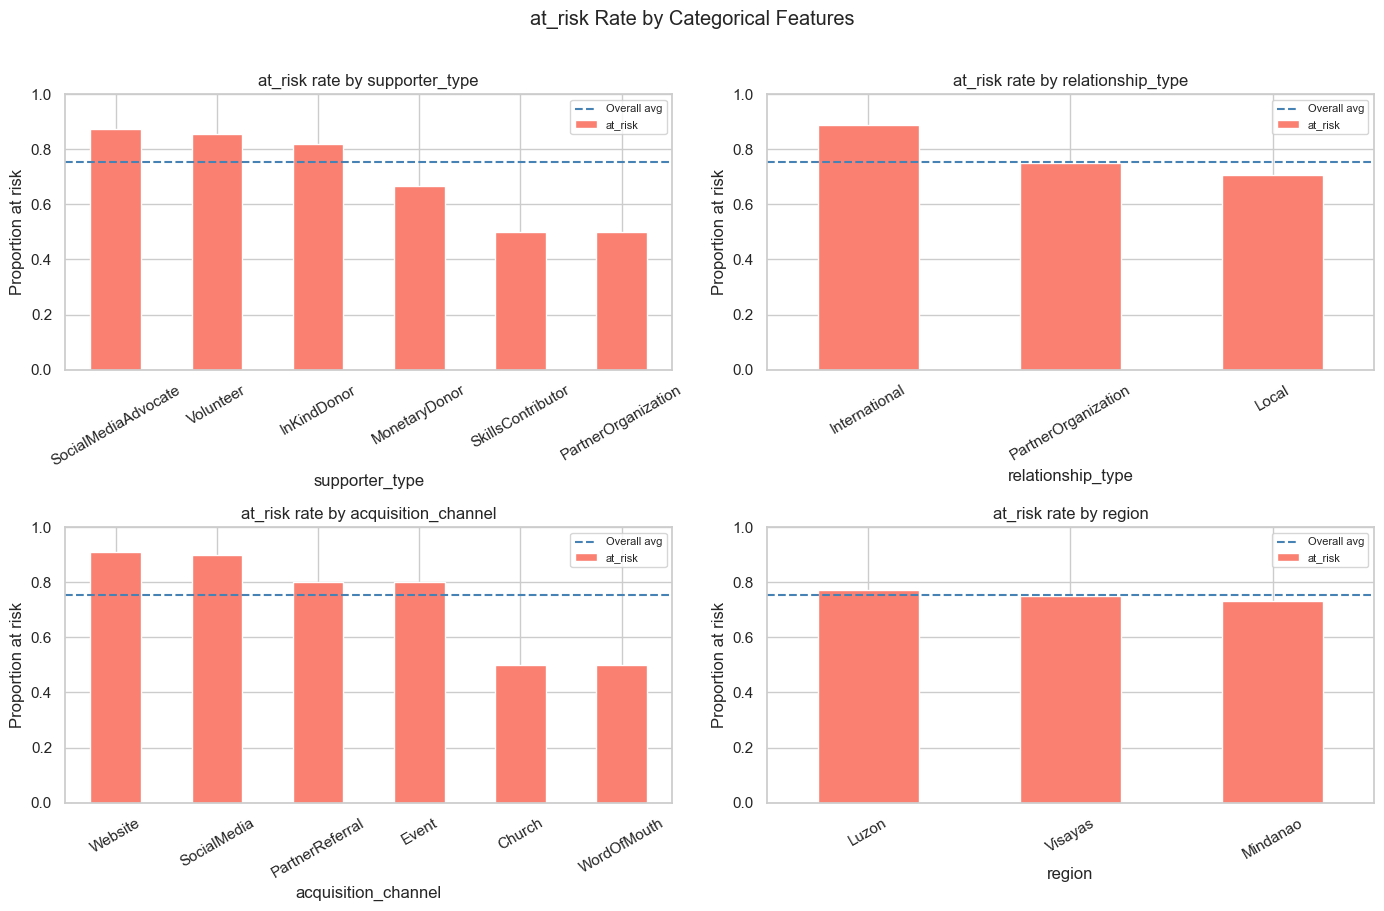

In [13]:
# at_risk rate by categorical features
cat_features = ['supporter_type', 'relationship_type', 'acquisition_channel', 'region']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, cat_features):
    risk_by_cat = active.groupby(col)['at_risk'].mean().sort_values(ascending=False)
    risk_by_cat.plot(kind='bar', ax=ax, color='salmon', rot=30)
    ax.set_title(f'at_risk rate by {col}')
    ax.set_ylabel('Proportion at risk')
    ax.set_ylim(0, 1)
    ax.axhline(active['at_risk'].mean(), color='steelblue', linestyle='--', label='Overall avg')
    ax.legend(fontsize=8)
plt.suptitle('at_risk Rate by Categorical Features', y=1.01)
plt.tight_layout()
plt.show()

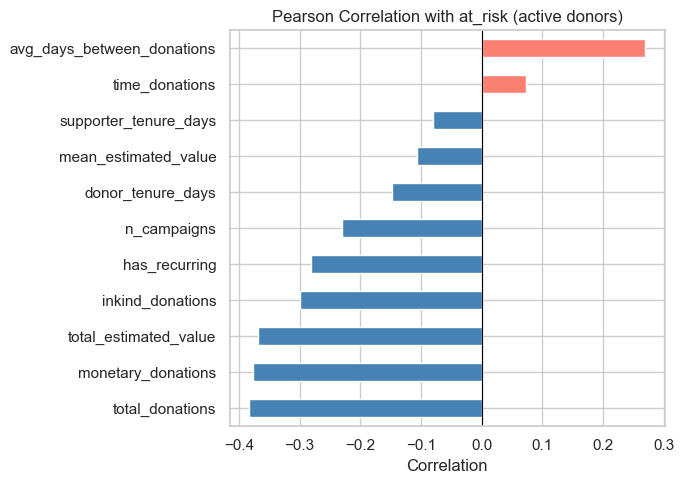

                             at_risk
total_donations            -0.382697
monetary_donations         -0.376619
total_estimated_value      -0.368361
inkind_donations           -0.299078
has_recurring              -0.281718
n_campaigns                -0.229794
donor_tenure_days          -0.147174
mean_estimated_value       -0.107236
supporter_tenure_days      -0.079631
time_donations              0.072647
avg_days_between_donations  0.269703


In [14]:
# Numeric feature correlation with at_risk
corr_cols = num_features + ['has_recurring', 'n_campaigns', 'monetary_donations',
                             'time_donations', 'inkind_donations', 'at_risk']
corr = active[corr_cols].corr()[['at_risk']].drop('at_risk').sort_values('at_risk')

fig, ax = plt.subplots(figsize=(7, 5))
corr['at_risk'].plot(kind='barh', ax=ax,
                     color=['salmon' if v > 0 else 'steelblue' for v in corr['at_risk']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with at_risk (active donors)')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print(corr.to_string())

In [15]:
# at_risk rate by recurring vs non-recurring
print('at_risk rate by has_recurring:')
print(active.groupby('has_recurring')['at_risk'].mean().rename({0: 'Non-recurring', 1: 'Recurring'}))

# at_risk rate by supporter_type — most actionable categorical feature
print('\nat_risk rate by supporter_type:')
print(active.groupby('supporter_type')['at_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False).round(2))

at_risk rate by has_recurring:
has_recurring
Non-recurring    0.833333
Recurring        0.571429
Name: at_risk, dtype: float64

at_risk rate by supporter_type:
                     mean  count
supporter_type                  
SocialMediaAdvocate  0.88      8
Volunteer            0.86      7
InKindDonor          0.82     11
MonetaryDonor        0.67     15
SkillsContributor    0.50      2
PartnerOrganization  0.50      2


## 2.8 Temporal Scope

Supporters created_at range: 2022-01-01 → 2022-10-23
Donations date range:        2023-01-09 → 2026-03-01


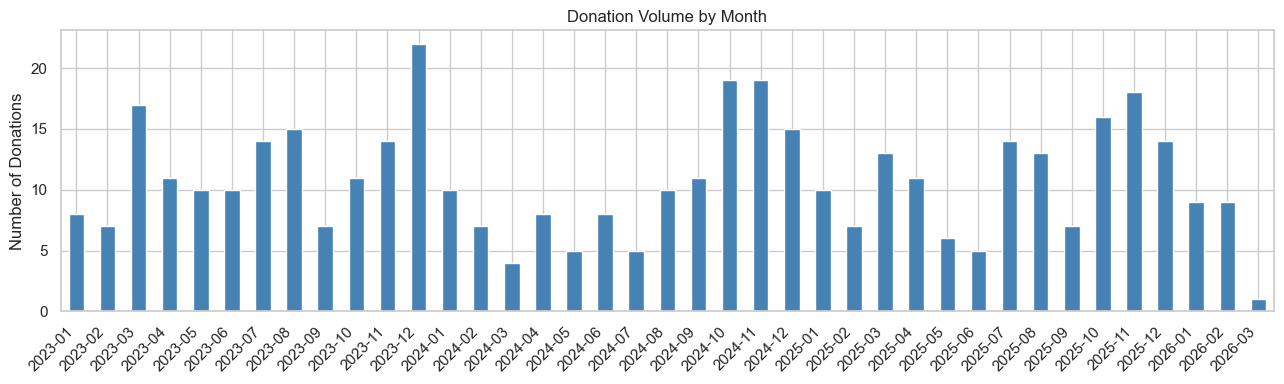


No seasonal pattern expected (user-confirmed). Plot above included for completeness.


In [16]:
print(f'Supporters created_at range: {supporters["created_at"].min().date()} → {supporters["created_at"].max().date()}')
print(f'Donations date range:        {donations["donation_date"].min().date()} → {donations["donation_date"].max().date()}')

# Donations per month
donations['month'] = donations['donation_date'].dt.to_period('M')
monthly = donations.groupby('month').size()

fig, ax = plt.subplots(figsize=(13, 4))
monthly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Donation Volume by Month')
ax.set_ylabel('Number of Donations')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nNo seasonal pattern expected (user-confirmed). Plot above included for completeness.')

## 2.9 Data Quality Issues — Summary

| Issue | Severity | Resolution (Phase 3) |
|---|---|---|
| `donations.amount` null for non-monetary | None — by design | Use `estimated_value` for all aggregations |
| `supporters.organization_name` / `first_name` / `last_name` null for orgs | None — by design | Drop from feature set (PII anyway) |
| `supporters.first_donation_date` 1 null | Low | Impute with `created_at` or leave; not used as direct feature |
| Donors with zero donations in history | Low | `days_since_last_donation` set to 9999 in `features.py`; `total_donations` = 0 |
| Small dataset (~60 donors) | Medium | Use regularized models; report wide CIs; interpret results with caution |

---

## Phase 2 Conclusion

**Data is well-understood and ready for preparation.**

Key findings:
- Two tables join cleanly on `supporter_id`
- `estimated_value` is the correct universal donation value metric
- No true data quality blockers — all nulls are by design or low-impact
- Promising features for predicting `at_risk`: `has_recurring`, `acquisition_channel`, `supporter_type`, `total_donations`, `avg_days_between_donations`
- Class imbalance is checked automatically — `class_weight='balanced'` will be applied if ratio ≥ 4:1
- No seasonality in donation patterns (user-confirmed)

---
**Proceed to Phase 3: Data Preparation →** `03_data_preparation.ipynb`